<a href="https://colab.research.google.com/github/ImNirajsingh/MNIST_digit_classification_cnn/blob/main/Copy_of_cnn_vision_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device : ", device)

Using device :  cuda


In [ ]:
transform = transforms.ToTensor()

train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Epoch 1/5, Loss: 281.6750
Epoch 2/5, Loss: 84.0372
Epoch 3/5, Loss: 60.4121
Epoch 4/5, Loss: 47.7313
Epoch 5/5, Loss: 37.6779
Accuracy on the test set: 98.65%
Model saved successfully.✅


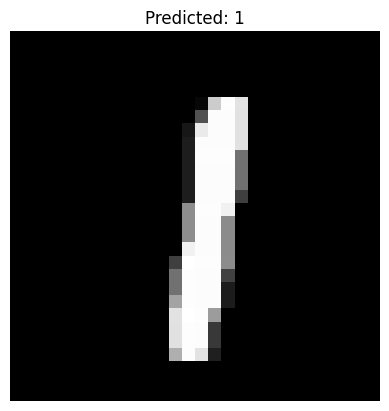

In [ ]:
class simpleCNN(nn.Module):
  def __init__(self):
    super(simpleCNN, self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 8, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(8, 16, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Linear(16 * 7 * 7, 64),
        nn.ReLU(inplace=True),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    x = self.features(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x


model = simpleCNN().to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss_value = loss(outputs, labels)
    loss_value.backward()
    optimizer.step()

    total_loss += loss_value.item()

  print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    predictions = outputs.argmax(dim=1)
    total += labels.size(0)
    correct += (predictions == labels).sum().item()

print(f"Accuracy on the test set: {100 * correct / total}%")

torch.save(model.state_dict(), 'simpleCNN_mnist.pth')
print("Model saved successfully.✅")

plt.imshow(images[0].cpu().squeeze(), cmap='gray')
plt.title(f"Predicted: {predictions[0].item()}")
plt.axis('off')
plt.show()